# FSD50K + CLAP + Pinecone — Audio Semantic Search
Build a semantic audio search engine using:
- **FSD50K** — 51k open-licensed sound event clips from Freesound (CC-licensed)
- **CLAP** — Contrastive Language-Audio Pretraining (text ↔ audio joint embedding)
- **Pinecone** — vector database for fast approximate nearest-neighbor search

You can query with either **text** ("find me rain sounds") or **audio** (upload a clip).


## 1  Install dependencies

In [ ]:
%pip install -q transformers datasets soundfile librosa torch torchaudio
%pip install -q pinecone
%pip install -q tqdm matplotlib IPython
%pip install -q nomic umap-learn

## 2  Imports & config

In [1]:
import os, io, warnings
warnings.filterwarnings("ignore")

import torch
import numpy as np
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from IPython.display import Audio, display

from datasets import load_dataset
from transformers import ClapModel, ClapProcessor
from pinecone import Pinecone, ServerlessSpec

PINECONE_API_KEY  = "Your"
INDEX_NAME        = "fsd50k-clap"
EMBEDDING_DIM     = 512
SAMPLE_RATE       = 48_000
MAX_DURATION_SEC  = 10
BATCH_SIZE        = 16
N_SAMPLES         = 500
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {DEVICE}")


Device: cuda


## 3  Load CLAP model
CLAP maps both audio and text into the **same 512-d vector space**, so a text query
and a matching audio clip end up close together. We use the LAION checkpoint
`laion/larger_clap_general` — trained on 633k audio-text pairs.


In [2]:
MODEL_ID = "laion/larger_clap_general"

print(f"Loading CLAP from {MODEL_ID} ...")
processor = ClapProcessor.from_pretrained(MODEL_ID)
model     = ClapModel.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()
print("CLAP ready.")


Loading CLAP from laion/larger_clap_general ...
CLAP ready.


## 4  Stream FSD50K from Hugging Face
FSD50K has 51,197 clips across 200 AudioSet classes. We stream a subset here —
change `N_SAMPLES` above to index more.

Dataset card: https://huggingface.co/datasets/Fhrozen/FSD50k


In [3]:
print("Streaming UrbanSound8K ...")
ds = load_dataset(
    "danavery/urbansound8k",
    split="train",
    streaming=True,
    trust_remote_code=True
)

sample = next(iter(ds))
for k, v in sample.items():
    if k != "audio":
        print(f"{k}: {v}")

Streaming UrbanSound8K ...
slice_file_name: 100032-3-0-0.wav
fsID: 100032
start: 0.0
end: 0.317551
salience: 1
fold: 5
classID: 3
class: dog_bark


## 5  Audio preprocessing helpers

In [4]:
def load_audio_from_sample(sample) -> np.ndarray:
    """Extract waveform from an HF audio sample dict, resample to CLAP's 48 kHz."""
    audio = sample["audio"]
    
    if isinstance(audio, dict) and "array" in audio:
        # Already decoded
        waveform = np.array(audio["array"], dtype=np.float32)
        sr = audio["sampling_rate"]
    elif isinstance(audio, dict) and "bytes" in audio:
        # Raw bytes — decode with soundfile
        buf = io.BytesIO(audio["bytes"])
        waveform, sr = sf.read(buf, dtype="float32")
        if waveform.ndim > 1:
            waveform = waveform.mean(axis=1)  # stereo -> mono
    else:
        raise ValueError(f"Unexpected audio format: {list(audio.keys())}")

    if sr != SAMPLE_RATE:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=SAMPLE_RATE)

    max_samples = MAX_DURATION_SEC * SAMPLE_RATE
    if len(waveform) > max_samples:
        waveform = waveform[:max_samples]
    else:
        waveform = np.pad(waveform, (0, max_samples - len(waveform)))

    return waveform


def plot_waveform_and_spectrogram(waveform: np.ndarray, title: str = ""):
    """Visualise a waveform and its mel spectrogram side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))

    t = np.linspace(0, len(waveform) / SAMPLE_RATE, len(waveform))
    axes[0].plot(t, waveform, linewidth=0.4, color="#185FA5")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Waveform")

    S = librosa.feature.melspectrogram(y=waveform, sr=SAMPLE_RATE, n_mels=128, fmax=24_000)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=SAMPLE_RATE, x_axis="time", y_axis="mel",
                                   fmax=24_000, ax=axes[1], cmap="magma")
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
    axes[1].set_title("Mel spectrogram")

    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


## 6  Inspect & listen to a sample clip

Label : dog_bark
Shape : (480000,)  (10.0 s @ 48000 Hz)


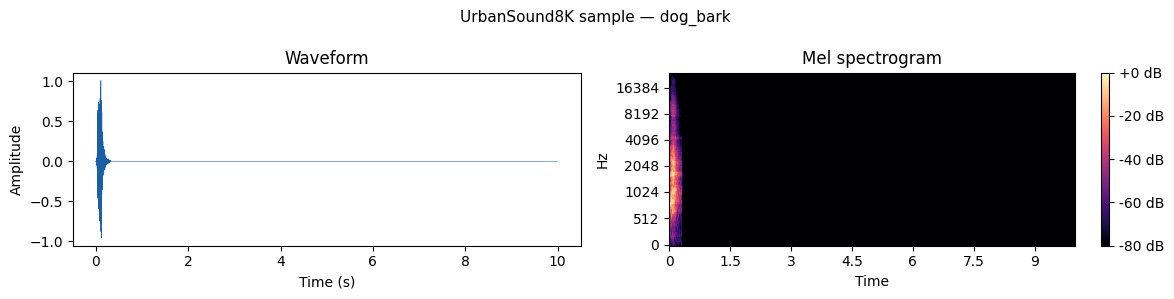

In [5]:
waveform = load_audio_from_sample(sample)
label    = sample.get("class") or str(sample.get("classID", "unknown"))

print(f"Label : {label}")
print(f"Shape : {waveform.shape}  ({len(waveform)/SAMPLE_RATE:.1f} s @ {SAMPLE_RATE} Hz)")

plot_waveform_and_spectrogram(waveform, title=f"UrbanSound8K sample — {label}")
display(Audio(data=waveform, rate=int(SAMPLE_RATE)))

## 7  CLAP embedding functions
Both audio and text go through the same projection head, landing in the same
512-d space. Cosine similarity between them gives a meaningful relevance score.


In [6]:
@torch.no_grad()
def embed_audio_batch(waveforms: list) -> np.ndarray:
    """Return L2-normalised CLAP audio embeddings, shape (B, 512)."""
    inputs = processor(
        audios=waveforms,
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        padding=True
    ).to(DEVICE)
    embs = model.get_audio_features(**inputs)
    embs = embs / embs.norm(dim=-1, keepdim=True)
    return embs.cpu().numpy()


@torch.no_grad()
def embed_text(text: str) -> np.ndarray:
    """Return L2-normalised CLAP text embedding, shape (512,)."""
    inputs = processor(text=[text], return_tensors="pt", padding=True).to(DEVICE)
    emb = model.get_text_features(**inputs)
    emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy()[0]


test_emb = embed_text("dog barking")
print(f"Text embedding shape: {test_emb.shape}, norm: {np.linalg.norm(test_emb):.4f}")


Text embedding shape: (512,), norm: 1.0000


## 8  Create Pinecone index
We use the **serverless** tier on AWS us-east-1 (free). Cosine metric matches
our L2-normalised embeddings (cosine = dot product when both sides are unit vectors).


In [7]:
pc = Pinecone(api_key=PINECONE_API_KEY)

if INDEX_NAME not in [idx.name for idx in pc.list_indexes()]:
    pc.create_index(
        name=INDEX_NAME,
        dimension=EMBEDDING_DIM,
        metric="cosine",
        spec=ServerlessSpec(cloud="aws", region="us-east-1")
    )
    print(f"Created index '{INDEX_NAME}'")
else:
    print(f"Index '{INDEX_NAME}' already exists — skipping creation")

index = pc.Index(INDEX_NAME)
print(index.describe_index_stats())


Index 'fsd50k-clap' already exists — skipping creation
DescribeIndexStatsResponse(dimension=512, total_vector_count=1000, metric='cosine', namespaces=1)


## 9  Embed & upsert FSD50K clips into Pinecone
Each clip is stored as a vector with metadata:
- `label` — AudioSet class name(s)
- `duration_s` — clip length in seconds
- `clip_id` — Freesound clip ID (if available)


In [8]:
ds_stream = load_dataset(
    "danavery/urbansound8k",
    split="train",
    streaming=True,
    trust_remote_code=True
)

batch_waveforms = []
batch_meta      = []
total_upserted  = 0
clip_idx        = 0

# Store for visualization later
viz_vecs   = []
viz_labels = []
viz_ids    = []

def flush_batch(waveforms, metas):
    embs = embed_audio_batch(waveforms)
    vectors = []
    for emb, meta in zip(embs, metas):
        vectors.append({
            "id":       meta["id"],
            "values":   emb.tolist(),
            "metadata": {k: v for k, v in meta.items() if k != "id"}
        })
        viz_vecs.append(emb)
        viz_labels.append(meta["label"])
        viz_ids.append(meta["id"])
    index.upsert(vectors=vectors)
    return len(vectors)


pbar = tqdm(total=N_SAMPLES, desc="Upserting")

for item in ds_stream:
    if clip_idx >= N_SAMPLES:
        break
    try:
        wav = load_audio_from_sample(item)
    except Exception as e:
        print(f"  skip clip {clip_idx}: {e}")
        clip_idx += 1
        continue

    label    = item.get("class") or str(item.get("classID", "unknown"))
    fname    = item.get("slice_file_name") or f"clip_{clip_idx}"
    clip_id  = Path(fname).stem
    duration = round(len(wav) / SAMPLE_RATE, 2)

    batch_waveforms.append(wav)
    batch_meta.append({
        "id":         clip_id,
        "label":      label,
        "duration_s": duration,
        "clip_idx":   clip_idx,
        "fname":      str(fname)
    })

    clip_idx += 1
    pbar.update(1)

    if len(batch_waveforms) == BATCH_SIZE:
        total_upserted += flush_batch(batch_waveforms, batch_meta)
        batch_waveforms = []
        batch_meta      = []

if batch_waveforms:
    total_upserted += flush_batch(batch_waveforms, batch_meta)

pbar.close()
viz_vecs = np.array(viz_vecs)
print(f"\nDone. Total vectors in index: {index.describe_index_stats()['total_vector_count']}")

Upserting:   0%|          | 0/500 [00:00<?, ?it/s]


Done. Total vectors in index: 1000


## 10  Text → audio search
Query the index with a natural-language description.


In [9]:
def search_by_text(query: str, top_k: int = 5) -> list:
    q_emb = embed_text(query)
    results = index.query(vector=q_emb.tolist(), top_k=top_k, include_metadata=True)
    return results["matches"]


def print_results(matches: list, query: str):
    print(f"\nQuery: '{query}'")
    print("-" * 50)
    for i, m in enumerate(matches, 1):
        meta = m["metadata"]
        print(f"  {i}. [{m['score']:.3f}]  {meta['label']:30s}  ({meta['duration_s']}s)  id={m['id']}")


for q in ["rain falling on a surface",
          "dog barking",
          "crowd cheering at a sports event",
          "alarm beeping",
          "acoustic guitar playing"]:
    matches = search_by_text(q, top_k=5)
    print_results(matches, q)


Query: 'rain falling on a surface'
--------------------------------------------------
  1. [0.386]  unknown                         (10s)  id=101676
  2. [0.312]  air_conditioner                 (10s)  id=100852-0-0-13
  3. [0.298]  air_conditioner                 (10s)  id=100852-0-0-11
  4. [0.292]  air_conditioner                 (10s)  id=100852-0-0-12
  5. [0.283]  air_conditioner                 (10s)  id=100852-0-0-18

Query: 'dog barking'
--------------------------------------------------
  1. [0.376]  dog_bark                        (10s)  id=101415-3-0-8
  2. [0.346]  dog_bark                        (10s)  id=105088-3-0-11
  3. [0.345]  dog_bark                        (10s)  id=105088-3-0-10
  4. [0.335]  dog_bark                        (10s)  id=103076-3-0-0
  5. [0.335]  dog_bark                        (10s)  id=101415-3-0-2

Query: 'crowd cheering at a sports event'
--------------------------------------------------
  1. [0.308]  unknown                         (10s)  id=

## 11  Audio → audio search
Query with an audio clip to find similar sounds.


In [12]:
def search_by_audio(waveform: np.ndarray, top_k: int = 5) -> list:
    embs = embed_audio_batch([waveform])
    results = index.query(vector=embs[0].tolist(), top_k=top_k, include_metadata=True)
    return results["matches"]


print("Query audio:")
display(Audio(data=waveform, rate=SAMPLE_RATE))

matches = search_by_audio(waveform, top_k=5)
print_results(matches, query=f"<audio clip: {label}>")


Query audio:



Query: '<audio clip: dog_bark>'
--------------------------------------------------
  1. [1.001]  dog_bark                        (10s)  id=100032-3-0-0
  2. [0.851]  dog_bark                        (10s)  id=103076-3-2-0
  3. [0.845]  dog_bark                        (10s)  id=103076-3-1-0
  4. [0.798]  dog_bark                        (10s)  id=107190-3-0-0
  5. [0.729]  dog_bark                        (10s)  id=103076-3-0-0


## 12  Metadata-filtered search
Pinecone lets you pre-filter by metadata before the ANN search kicks in.


In [14]:
def search_with_filter(query: str, label_contains: str = None,
                       max_duration: float = None, top_k: int = 5) -> list:
    q_emb  = embed_text(query)
    pinecone_filter = {}

    if label_contains:
        pinecone_filter["label"] = {"$eq": label_contains}
    if max_duration:
        pinecone_filter["duration_s"] = {"$lte": max_duration}

    results = index.query(
        vector=q_emb.tolist(),
        top_k=top_k,
        include_metadata=True,
        filter=pinecone_filter if pinecone_filter else None
    )
    return results["matches"]


matches = search_with_filter("dog barks", max_duration=5.0, top_k=5)
print_results(matches, "dog barks (max 5 s)")



Query: 'dog barks (max 5 s)'
--------------------------------------------------


## 13  Visualise similarity between queries
Build a cosine similarity matrix across multiple text queries.


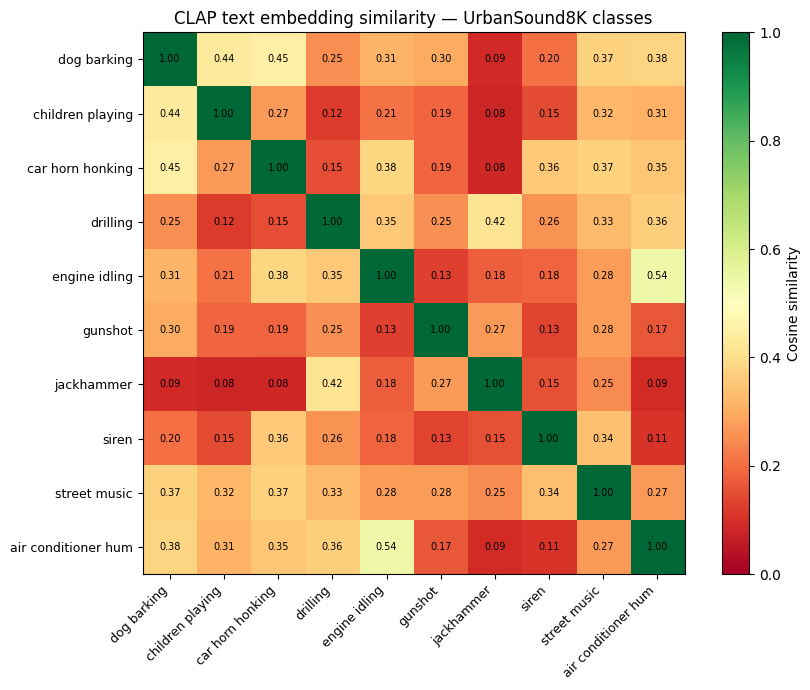

In [15]:
queries = [
    "dog barking",
    "children playing",
    "car horn honking",
    "drilling",
    "engine idling",
    "gunshot",
    "jackhammer",
    "siren",
    "street music",
    "air conditioner hum"
]

embs = np.stack([embed_text(q) for q in queries])
sim_matrix = embs @ embs.T

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Cosine similarity")

ax.set_xticks(range(len(queries)))
ax.set_yticks(range(len(queries)))
ax.set_xticklabels(queries, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(queries, fontsize=9)
ax.set_title("CLAP text embedding similarity — UrbanSound8K classes")

for i in range(len(queries)):
    for j in range(len(queries)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center",
                fontsize=7, color="black")

plt.tight_layout()
plt.show()

## 14  Visualise embedding space with PCA
Project indexed audio embeddings to 2D to see how sound categories cluster.


Fitting UMAP 3D projection ...


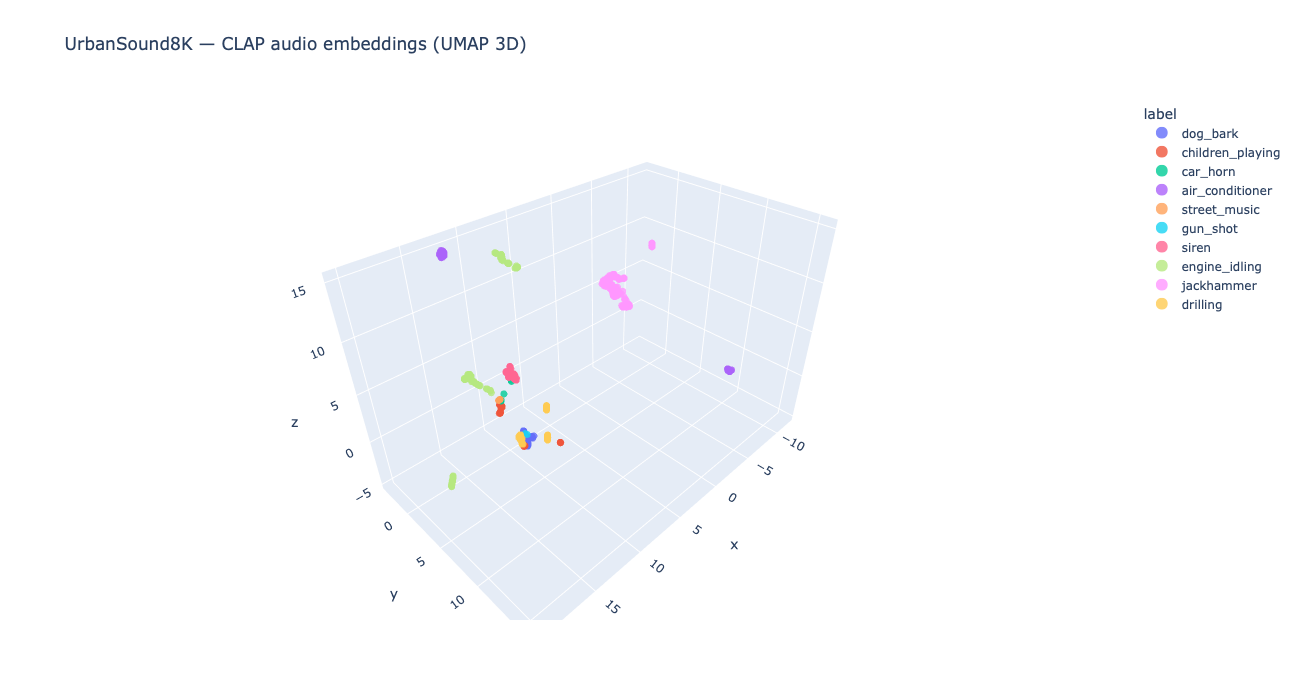

In [16]:
import umap
import plotly.express as px
import pandas as pd

print("Fitting UMAP 3D projection ...")
reducer = umap.UMAP(n_components=3, random_state=42, n_neighbors=15, min_dist=0.1)
X3d = reducer.fit_transform(viz_vecs)

df = pd.DataFrame({
    "x": X3d[:, 0],
    "y": X3d[:, 1],
    "z": X3d[:, 2],
    "label": viz_labels,
    "id": viz_ids
})

fig = px.scatter_3d(
    df, x="x", y="y", z="z",
    color="label",
    hover_data=["id", "label"],
    title="UrbanSound8K — CLAP audio embeddings (UMAP 3D)",
    opacity=0.8,
    height=700
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(legend=dict(itemsizing="constant"))
fig.show()

## 15  Clean up (optional)
Delete the index when done to avoid storage costs on the free tier.


In [ ]:
# Uncomment to delete the index
# pc.delete_index(INDEX_NAME)
# print(f"Deleted index '{INDEX_NAME}'")

print("Index stats:", index.describe_index_stats())


---
## Tips & next steps

| What | How |
|------|-----|
| **Index all 51k clips** | Set `N_SAMPLES = 51197` and use `split="train"` |
| **Speed up embedding** | Use a GPU (Colab T4 is free) or reduce `MAX_DURATION_SEC` |
| **Better accuracy** | Use `laion/clap-htsat-fused` instead of the general checkpoint |
| **Add Whisper transcripts** | For speech clips, run Whisper and store transcript in metadata |
| **Production scale** | Use Pinecone's `p2` pod type or increase replicas |
| **Hybrid search** | Combine Pinecone vector search with BM25 keyword filter on the label field |
